# Probabilistic equivalence analysis

## Accuracy analysis

In [24]:
from src import Plot, successRatioBy, printMeanDecrease, printAccuracy

cancellationPath = "data/probabilisticEq/cancellation_accuracy.csv"
commutativePath = "data/probabilisticEq/commutation_accuracy.csv"
idempotencyPath = "data/probabilisticEq/idempotency_accuracy.csv"


def addSuccessRatioComparison(plot, csvPath):
    plot.add(
        csvPath,
        lambda data: successRatioBy(
            data,
            xColumn="numOfStates",
            filters={"useSrs": 0},
        ),
        label="Without SRS",
    )
    plot.add(
        csvPath,
        lambda data: successRatioBy(
            data,
            xColumn="numOfStates",
            filters={"useSrs": 1},
        ),
        label="With SRS",
    )

## Commutativity

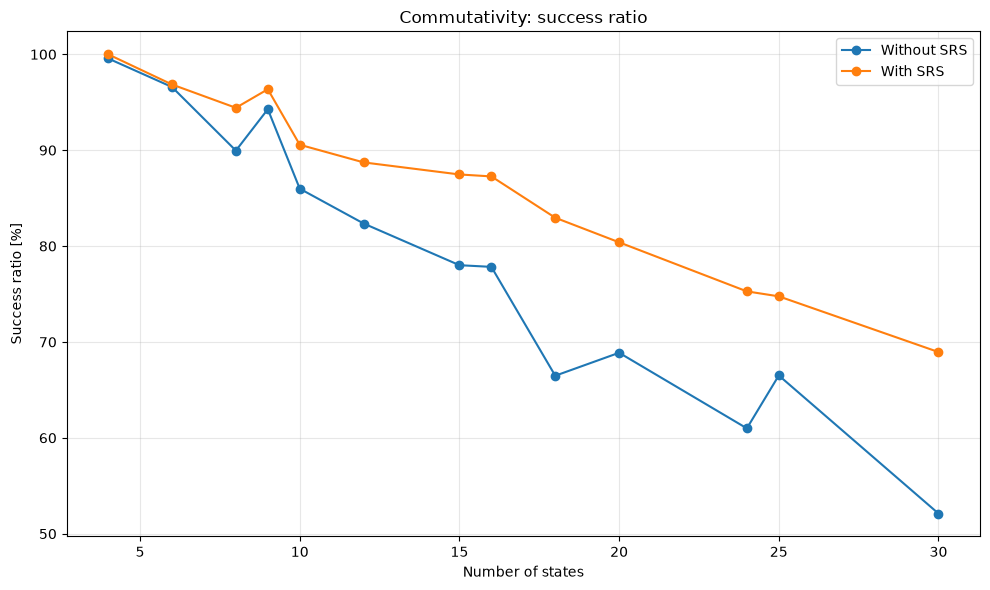

In [25]:
commutativitySuccessPlot = Plot(
    title="Commutativity: success ratio",
    xLabel="Number of states",
    yLabel="Success ratio [%]",
)
addSuccessRatioComparison(commutativitySuccessPlot, commutativePath)
commutativitySuccessPlot.draw()

In [26]:
printAccuracy(commutativePath)

Accuracy without SRS 80.50% and with SRS 87.75%  (all automata)
Average accurtacy gain 9.01%  (all automata)
Accuracy without SRS 87.97% and with SRS 92.50%  (automata with at most 15 states)
Average accurtacy gain 5.15%  (automata with at most 15 states)
Accuracy without SRS 66.23% and with SRS 78.68%  (automata with at least 15 states)
Average accurtacy gain 18.79%  (automata with at least 15 states)


## Cancellation

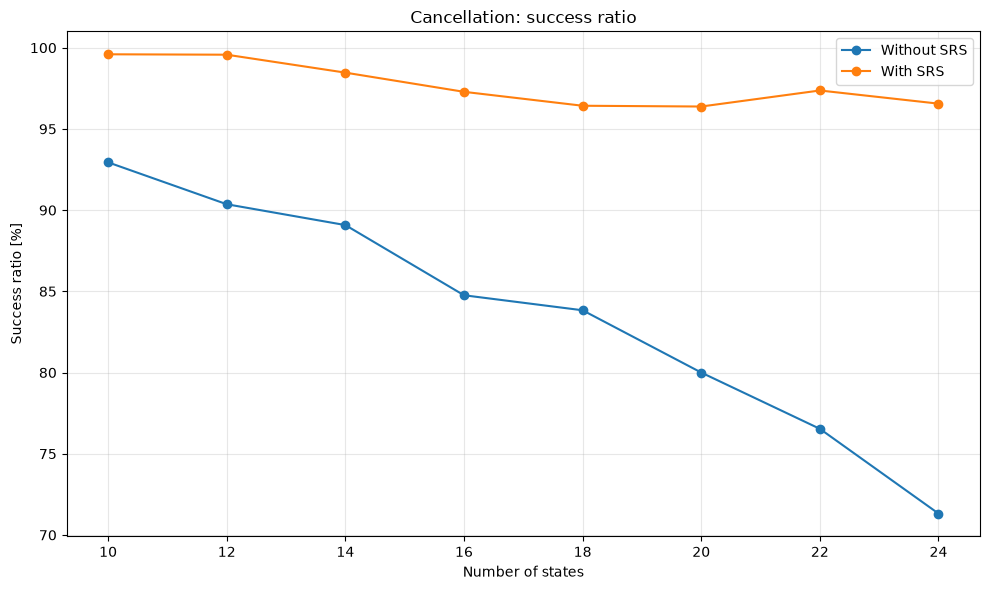

In [28]:
cancellationSuccessPlot = Plot(
    title="Cancellation: success ratio",
    xLabel="Number of states",
    yLabel="Success ratio [%]",
)
addSuccessRatioComparison(cancellationSuccessPlot, cancellationPath)
cancellationSuccessPlot.draw()

In [29]:
printAccuracy(cancellationPath)

Accuracy without SRS 83.55% and with SRS 97.67%  (all automata)
Average accurtacy gain 16.91%  (all automata)
Accuracy without SRS 90.77% and with SRS 99.19%  (automata with at most 15 states)
Average accurtacy gain 9.27%  (automata with at most 15 states)
Accuracy without SRS 79.28% and with SRS 96.78%  (automata with at least 15 states)
Average accurtacy gain 22.07%  (automata with at least 15 states)


## Idempotency

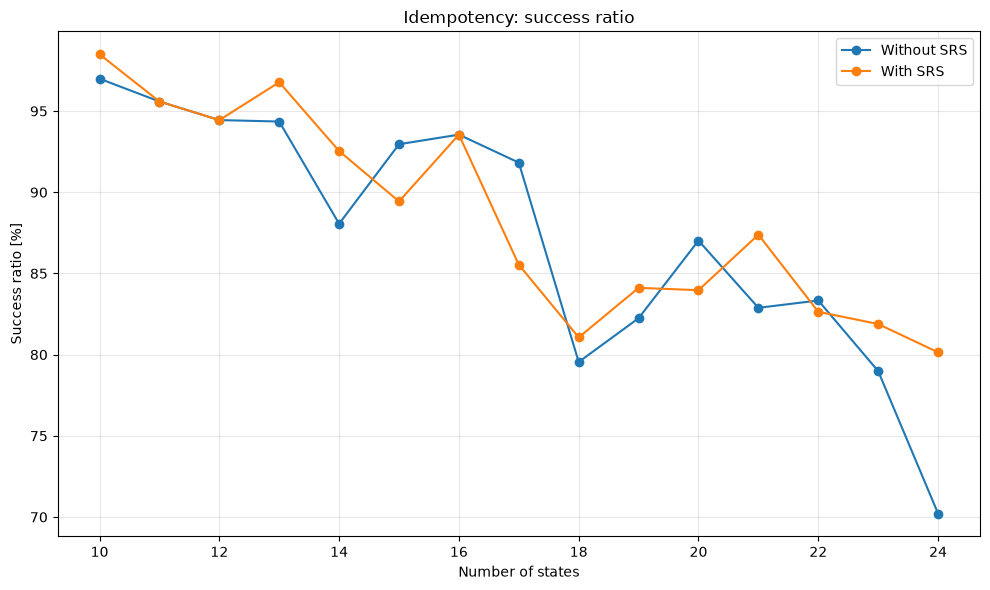

In [21]:
idempotencySuccessPlot = Plot(
    title="Idempotency: success ratio",
    xLabel="Number of states",
    yLabel="Success ratio [%]",
)
addSuccessRatioComparison(idempotencySuccessPlot, idempotencyPath)
idempotencySuccessPlot.draw()

In [22]:
printAccuracy(idempotencyPath)

Accuracy without SRS 87.55% and with SRS 88.45%  (all automata)
Average accurtacy gain 1.03%  (all automata)
Accuracy without SRS 93.73% and with SRS 94.46%  (automata with at most 15 states)
Average accurtacy gain 0.79%  (automata with at most 15 states)
Accuracy without SRS 83.32% and with SRS 84.33%  (automata with at least 15 states)
Average accurtacy gain 1.21%  (automata with at least 15 states)


## Equivalence analysis

In [31]:
from src import Plot, meanBy, printMeanDecrease
import pandas as pd

cancellationPath = (
    "data/exactEq/cancellation_increasing_number_of_states.csv"
)
commutativePath = (
    "data/exactEq/commutation_increasing_number_of_states.csv"
)
idempotencyPath = (
    "data/exactEq/idempotency_increasing_number_of_states.csv"
)


def addMeanComparison(plot, csvPath, yColumn, scale=1):
    plot.add(
        csvPath,
        lambda data: meanBy(
            data,
            xColumn="numOfStates",
            yColumn=yColumn,
            filters={"useSrs": 0},
        ) / scale,
        label="Without SRS",
    )
    plot.add(
        csvPath,
        lambda data: meanBy(
            data,
            xColumn="numOfStates",
            yColumn=yColumn,
            filters={"useSrs": 1},
        ) / scale,
        label="With SRS",
    )

### Commutativity

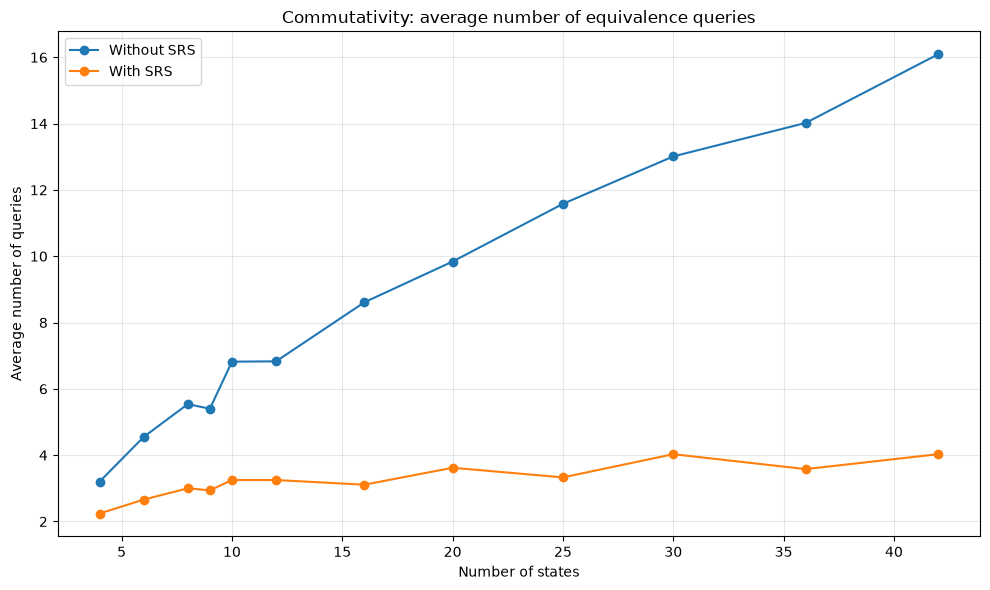

In [32]:
commutativityQueriesPlot = Plot(
    title="Commutativity: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    commutativityQueriesPlot,
    commutativePath,
    yColumn="equivalenceQueryCount",
)
commutativityQueriesPlot.draw()

In [35]:
printMeanDecrease(commutativePath)

Average procentage reduction in equivalence queries 62.99%


## Cancellation

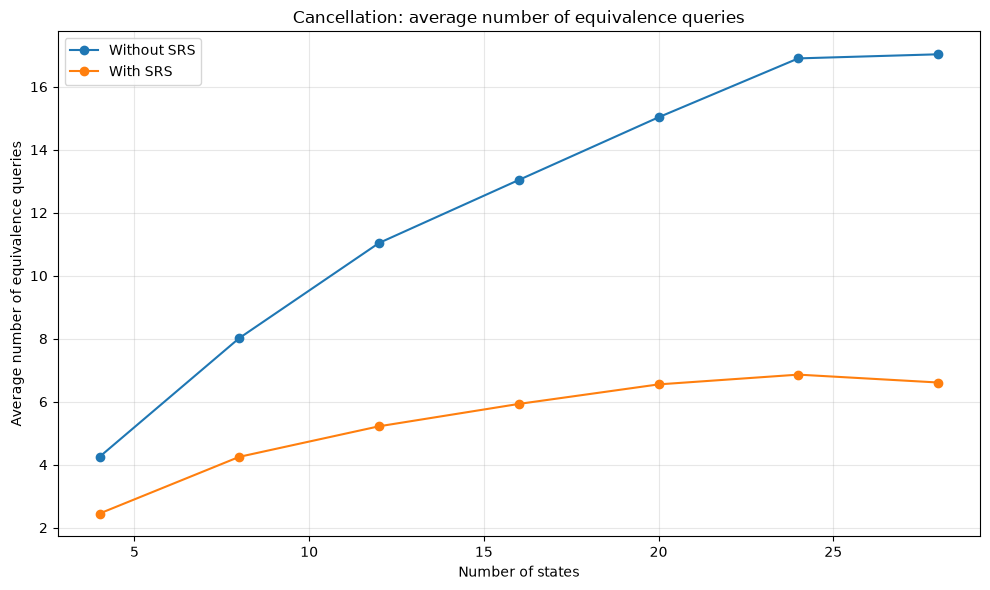

In [37]:
cancellationQueriesPlot = Plot(
    title="Cancellation: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of equivalence queries",
)
addMeanComparison(
    cancellationQueriesPlot,
    cancellationPath,
    yColumn="equivalenceQueryCount",
)
cancellationQueriesPlot.draw()

In [36]:
printMeanDecrease(cancellationPath)

Average procentage reduction in equivalence queries 55.61%


## Idempotency

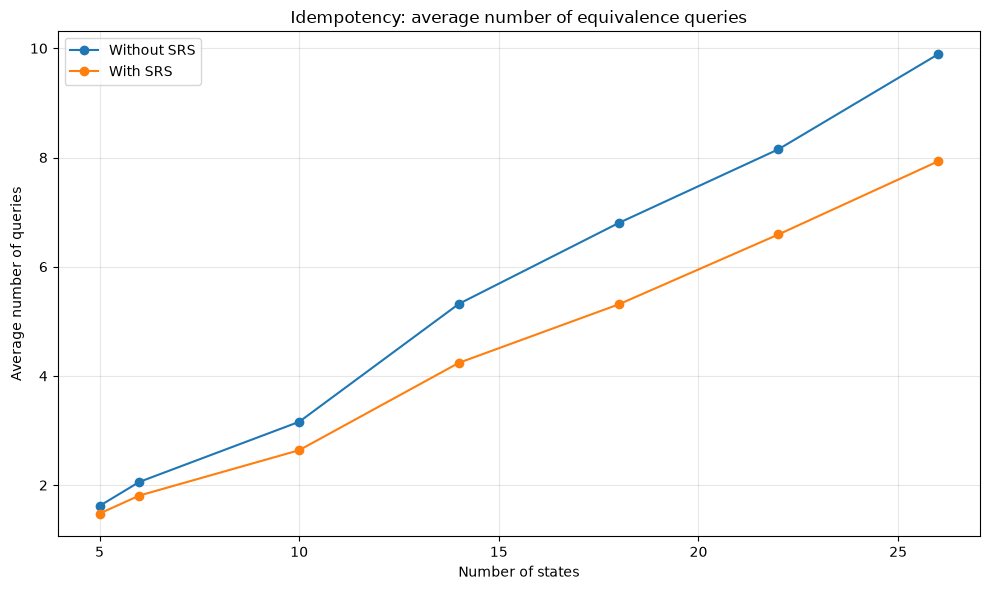

In [38]:
idempotencyQueriesPlot = Plot(
    title="Idempotency: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    idempotencyQueriesPlot,
    idempotencyPath,
    yColumn="equivalenceQueryCount",
)
idempotencyQueriesPlot.draw()

In [39]:
printMeanDecrease(idempotencyPath)

Average procentage reduction in equivalence queries 18.92%
